# Relax Inc. Take-Home Challenge

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from category_encoders import TargetEncoder 

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Read takehome_user_engagement CSV file
df_eng = pd.read_csv("takehome_user_engagement.csv")

df_eng

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1
...,...,...,...
207912,2013-09-06 06:14:15,11996,1
207913,2013-01-15 18:28:37,11997,1
207914,2014-04-27 12:45:16,11998,1
207915,2012-06-02 11:55:59,11999,1


In [3]:
# Read takehome_users CSV file
df_users = pd.read_csv("takehome_users.csv", encoding="latin-1")

df_users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,22/04/2014 03:53,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,15/11/2013 03:45,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,19/03/2013 23:14,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,21/05/2013 08:09,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,17/01/2013 10:14,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


**Relax Inc. Take-Home Challenge - Case Details:**

Defining an "adopted user" as a user who has logged into the product on three separatedays in at least one sevenday
period , identify which factors predict future useradoption .

Please send us a brief writeup of your findings (the more concise, the better no morethan one page), 
along with any summary tables, graphs, code, or queries that can help
us understand your approach. 

Please note any factors you considered or investigation you did, 
even if they did not pan out. Feel free to identify any further research or data you think would be valuable.

# Business Question (Refined):

Which characteristics of newly registered users best predict whether they will become adopted users?

This is a **binary classification problem**.

**Target Variable:** Logged into the application on at least 3 different days within any rolling 7-day period.



adopted_user

1 = Adopted

0 = Not Adopted

In [4]:
# Inspect the data

df_eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB


In [5]:
# Inspect the data

df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [6]:
# Inspect the data

df_eng.describe()

,user_id,visited
count,207917.000000,207917.0
mean,5913.314197,1.0
std,3394.941674,0.0
min,1.000000,1.0
25%,3087.000000,1.0
50%,5682.000000,1.0
75%,8944.000000,1.0
max,12000.000000,1.0


In [7]:
# Inspect the data

df_users.describe()

,object_id,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
count,12000.00000,8.823000e+03,12000.000000,12000.000000,12000.000000,6417.000000
mean,6000.50000,1.379279e+09,0.249500,0.149333,141.884583,5962.957145
std,3464.24595,1.953116e+07,0.432742,0.356432,124.056723,3383.761968
min,1.00000,1.338452e+09,0.000000,0.000000,0.000000,3.000000
25%,3000.75000,1.363195e+09,0.000000,0.000000,29.000000,3058.000000
50%,6000.50000,1.382888e+09,0.000000,0.000000,108.000000,5954.000000
75%,9000.25000,1.398443e+09,0.000000,0.000000,238.250000,8817.000000
max,12000.00000,1.402067e+09,1.000000,1.000000,416.000000,11999.000000


In [8]:
# Check for missing data in engagement df

df_eng.isna().sum()

time_stamp    0
user_id       0
visited       0
dtype: int64

In [9]:
# Check for missing data in users df

df_users.isna().sum().sort_values(ascending=False)

invited_by_user_id            5583
last_session_creation_time    3177
creation_time                    0
object_id                        0
email                            0
name                             0
creation_source                  0
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
dtype: int64

Approximately 5,583 users have missing values for invited_by_user_id.

This missingness is expected rather than an indication of poor data quality. Users who registered directly through the website or Google Authentication were not invited by another user; therefore, no inviter exists.

Instead of removing these observations, the missing values are treated as meaningful information.

Create an indicator variable showing whether the user was invited.

In [10]:
# Create a binary feature indicating whether a user was invited. 
# The raw inviter ID is then dropped because it is merely an
# identifier with no inherent predictive value and could introduce spurious patterns into the model.
df_users["was_invited"] = df_users["invited_by_user_id"].notna().astype(int)


# Convert Unix timestamp to datetime for inspection only.
df_users["last_session_creation_time"] = pd.to_datetime(df_users["last_session_creation_time"],unit="s",errors="coerce")
df_users["last_session_creation_time"].isna().sum()

np.int64(3177)

Approximately 3,177 users have no recorded last login.

Although this likely indicates **users who never logged in after registration**, this **variable ("invited_by_user_id")** contains information that occurs after account creation.

Since the objective is to predict future adoption using information available at signup, this **variable introduces target leakage.**

Therefore, **it will not be used for feature engineering or modeling.**

Approximately **3,177 users have no recorded last login**, suggesting that these users either never logged in after registration or that no subsequent login activity was recorded.

The variable **`last_session_creation_time`** captures a user's most recent login activity, which occurs **after account registration**. Because the objective is to predict whether a **newly registered user** will become an adopted user using only information available **at the time of signup**, this variable would not be available when making real-time predictions. Consequently, it is excluded from feature engineering and model development to ensure the model reflects a realistic deployment scenario.

In contrast, **`invited_by_user_id`** is available at the time of registration for users who join via an invitation and therefore does **not** introduce target leakage. Although the raw identifier itself has little predictive value because it is a high-cardinality identifier, it can be transformed into more informative features (e.g., the total number of users invited by each inviter) that capture the influence or activity level of the inviter while remaining available at prediction time.

In [11]:
# Remove the variable to prevent target leakage.
df_users.drop(columns="last_session_creation_time",inplace=True)

In [12]:
# Check duplicate user records.

df_users.duplicated().sum()

np.int64(0)

In [13]:
# Check duplicate login records.

df_eng.duplicated().sum()

np.int64(0)

In [14]:
# Convert account creation timestamp.

df_users["creation_time"] = pd.to_datetime(df_users["creation_time"])

df_users["creation_time"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 12000 entries, 0 to 11999
Series name: creation_time
Non-Null Count  Dtype         
--------------  -----         
12000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 93.9 KB


In [15]:
# Convert login timestamps from engagement table.

df_eng["time_stamp"] = pd.to_datetime(df_eng["time_stamp"])
df_eng["time_stamp"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 207917 entries, 0 to 207916
Series name: time_stamp
Non-Null Count   Dtype         
--------------   -----         
207917 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.6 MB


In [16]:
# Create Adorption function
# The algorithm slides a 7-day window across a user's login history and 
# Checks whether at least three unique login days fall within any such window. 
# If they do, the user is classified as an adopted user.

def adopted_user(login_dates):
    """
    Returns 1 if a user logged in on at least three different days
    within any rolling seven-day period; otherwise returns 0.
    """

    login_dates = (
        login_dates
        .sort_values()
        .drop_duplicates()
        .reset_index(drop=True)
    )

    left = 0

    for right in range(len(login_dates)):

        while (
            login_dates.iloc[right]
            - login_dates.iloc[left]
        ).days > 6:

            left += 1

        if right - left + 1 >= 3:

            return 1

    return 0

In [17]:
# Create the target variable for every user by applying the adopted_user function

adoption = (df_eng.groupby("user_id")["time_stamp"].apply(adopted_user).reset_index(name="adopted_user"))

In [18]:
# Inspect the distribution of adopted_user

print(adoption["adopted_user"].info())
print()
print(adoption["adopted_user"].value_counts())
print()
print(adoption["adopted_user"].value_counts(normalize=True))

<class 'pandas.core.series.Series'>
RangeIndex: 8823 entries, 0 to 8822
Series name: adopted_user
Non-Null Count  Dtype
--------------  -----
8823 non-null   int64
dtypes: int64(1)
memory usage: 69.1 KB
None

adopted_user
0    7221
1    1602
Name: count, dtype: int64

adopted_user
0    0.818429
1    0.181571
Name: proportion, dtype: float64


In [19]:
# Merge user attributes with the adoption labels.
# Users with no login records will have missing adoption labels after the
# left join and are classified as non-adopted.

df_users = df_users.merge(adoption, left_on="object_id", right_on="user_id",how="left")
df_users["adopted_user"] = (df_users["adopted_user"].fillna(0).astype(int))

# Remove the duplicate merge key from the adoption table.
df_users = df_users.drop(columns=["user_id"])

In [20]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  object        
 3   email                       12000 non-null  object        
 4   creation_source             12000 non-null  object        
 5   opted_in_to_mailing_list    12000 non-null  int64         
 6   enabled_for_marketing_drip  12000 non-null  int64         
 7   org_id                      12000 non-null  int64         
 8   invited_by_user_id          6417 non-null   float64       
 9   was_invited                 12000 non-null  int64         
 10  adopted_user                12000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(3)


In [21]:
# Inspect of users table
df_users.sample(10)

,object_id,creation_time,name,email,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,was_invited,adopted_user
7850,7851,2012-08-07 23:34:00,Søndergaard Lasse,LasseLSndergaard@jourrapide.com,GUEST_INVITE,1,0,221,7851.0,1,0
10814,10815,2014-02-14 06:09:00,Herrmann Barbara,BarbaraHerrmann@yahoo.com,SIGNUP,0,0,54,NaN,0,0
2295,2296,2013-08-02 07:19:00,Klug Jennifer,JenniferKlug@jourrapide.com,ORG_INVITE,1,0,271,5166.0,1,0
5515,5516,2012-08-15 21:10:00,McGee Yolanda,YolandaRMcGee@jourrapide.com,ORG_INVITE,1,0,91,5516.0,1,1
11277,11278,2014-02-20 13:13:00,Tanner Joyce,JoyceATanner@gmail.com,SIGNUP_GOOGLE_AUTH,0,0,132,NaN,0,0
2130,2131,2013-03-02 12:09:00,Buss Jordan,JordanBuss@gustr.com,GUEST_INVITE,0,1,141,2131.0,1,0
4972,4973,2013-06-29 19:34:00,Clausen Christina,ChristinaDClausen@yahoo.com,GUEST_INVITE,0,0,289,445.0,1,0
5552,5553,2013-09-18 16:22:00,Costa Manuela,ManuelaFerreiraCosta@yahoo.com,ORG_INVITE,1,0,132,2078.0,1,0
10220,10221,2012-10-11 18:48:00,Burrows Harry,HarryBurrows@jourrapide.com,GUEST_INVITE,0,0,374,10221.0,1,0
2385,2386,2013-03-16 02:09:00,Bech Olivia,OliviaMBech@hotmail.com,PERSONAL_PROJECTS,0,0,109,NaN,0,0


### Feature Engineering

Additional variables that may help explain user adoption.

In [22]:
# Organization Size - Users belonging to larger organizations may have different engagement behaviour due to stronger network effects.
org_size = df_users.groupby("org_id").size().rename("org_size")
df_users = df_users.merge(org_size, on="org_id")

# Account-Age is important because some users joined the platform over a two-year period hence, had more time 
# to satisfy the adoption criterion than others.
# Account age is included as a control variable to account for differences in observation time
reference_date = df_eng["time_stamp"].max()
df_users["account_age_days"] = (reference_date - df_users["creation_time"]).dt.days

# Signup Month feature
df_users["signup_month"] = df_users["creation_time"].dt.month

# Signup Week
df_users["signup_weekday"] = df_users["creation_time"].dt.day_name()

# Signup Hour
df_users["signup_hour"] = (df_users["creation_time"].dt.hour)

# Indicator for Large Organizations
# Organizations with size greater than or equal to the median are considered relatively large.
median_size = df_users["org_size"].median()
df_users["large_org"] = (df_users["org_size"] >= median_size).astype(int)


# Invitation into a Large Organization Indicator
# Being invited into a large organization may provide stronger onboarding support and greater opportunities for engagement.
# Invited into a Large Organization
df_users["invited_to_large_org"] = (
    (df_users["was_invited"] == 1) &
    (df_users["org_size"] >= median_size)
).astype(int)

# User's email domain.
# Retain only the six most common domains and group all remaining
# domains into an "other" category to reduce cardinality and improve
# model generalization.
df_users["email_domain"] = df_users["email"].str.split("@").str[1].str.lower()
top = df_users["email_domain"].value_counts().nlargest(6).index
df_users["email_domain"] = df_users["email_domain"].where(
    df_users["email_domain"].isin(top),"other")

# Number of users invited by each inviter.
# This captures the influence or activity level of the inviter, as users
# recruited by highly active inviters may exhibit different adoption
# patterns than those invited by users who invited only a few people.
# The original inviter ID is later dropped because it is a unique identifier
# with no inherent predictive meaning.
invite_counts = df_users["invited_by_user_id"].value_counts()
df_users["inviter_total_invites"] = (
    df_users["invited_by_user_id"].map(invite_counts).fillna(0))

In [23]:
# Review Engineered features
df_users[
    [
        "org_size",
        "large_org",
        "was_invited",
        "invited_to_large_org",
        "account_age_days",
        "signup_month",
        "signup_weekday",
        "email_domain",
        "signup_hour"
    ]
]    .sample(10)

,org_size,large_org,was_invited,invited_to_large_org,account_age_days,signup_month,signup_weekday,email_domain,signup_hour
8885,23,0,0,0,15,5,Wednesday,gmail.com,19
3966,128,1,0,0,122,2,Tuesday,gmail.com,10
7752,17,0,0,0,728,6,Friday,jourrapide.com,10
3234,16,0,0,0,286,8,Saturday,other,5
488,233,1,0,0,540,12,Thursday,yahoo.com,4
1089,24,0,1,0,623,9,Friday,cuvox.de,9
11507,42,1,0,0,180,12,Saturday,gmail.com,15
4615,39,1,1,1,456,3,Thursday,yahoo.com,6
9760,26,0,0,0,160,12,Saturday,jourrapide.com,13
1743,25,0,0,0,95,3,Monday,cuvox.de,7


### Exploratory Data Analysis

adopted_user
0    0.8665
1    0.1335
Name: proportion, dtype: float64



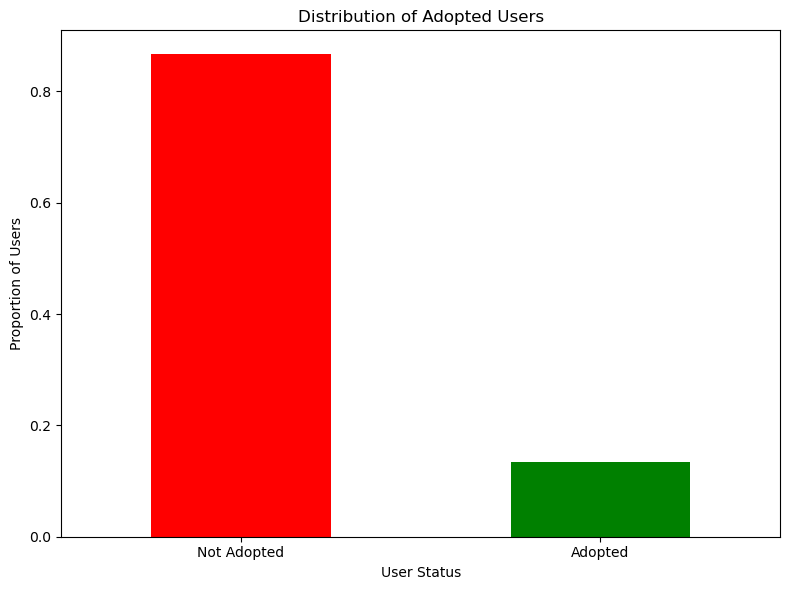

In [24]:
# Overall Adoption Rate
print(df_users["adopted_user"].value_counts(normalize=True))
print()

# Visualize  Adoption Rate
plt.figure(figsize=(8,6))

ax= df_users["adopted_user"].value_counts(normalize=True).plot(kind="bar",color=["red", "green"])
ax.set_xticklabels(["Not Adopted", "Adopted"], rotation=0)
ax.set_xlabel("User Status")
ax.set_ylabel("Proportion of Users")
ax.set_title("Distribution of Adopted Users")

plt.tight_layout()
plt.show()

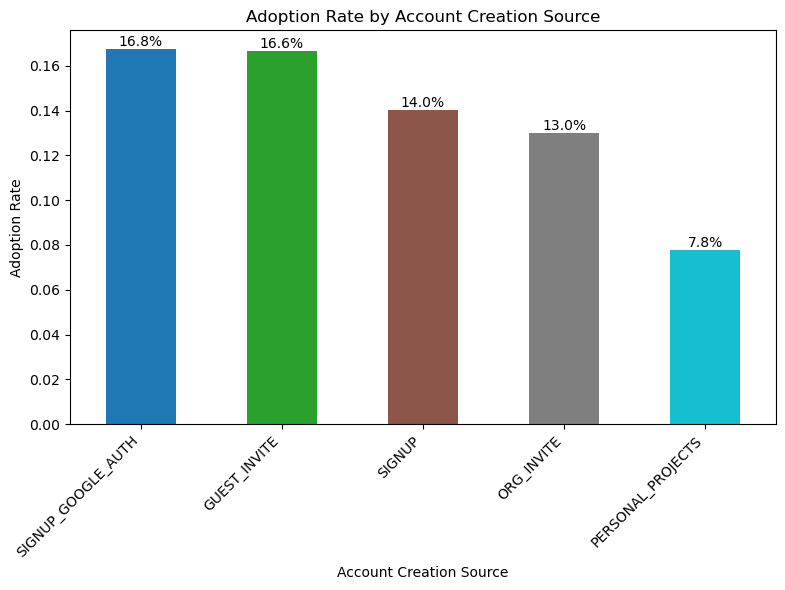

In [25]:
# Adoption Rate by Account Creation Source
# It answer the question that among users created through this source, what percentage became adopted?
adoption_rate_by_source = (df_users.groupby("creation_source")["adopted_user"].mean().sort_values(ascending=False))

plt.figure(figsize=(8, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(adoption_rate_by_source)))
ax = (
    df_users
    .groupby("creation_source")["adopted_user"]
    .mean()
    .sort_values(ascending=False)
    .plot(
        kind="bar",
        color=colors
    )
)

ax.set_xlabel("Account Creation Source")
ax.set_ylabel("Adoption Rate")
ax.set_title("Adoption Rate by Account Creation Source")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Display adoption rate on each bar
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

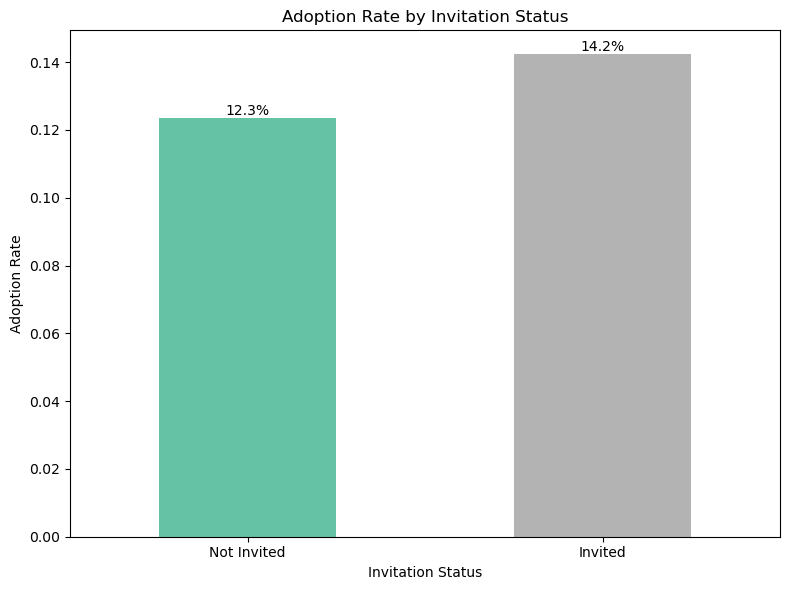

In [26]:
# Adoption rate by invitation status

adoption_rate_by_invitation = (
    df_users
    .groupby("was_invited")["adopted_user"]
    .mean()
)

plt.figure(figsize=(8, 6))

ax = adoption_rate_by_invitation.plot(
    kind="bar",
    color=plt.cm.Set2(np.linspace(0, 1, len(adoption_rate_by_invitation)))
)

ax.set_xlabel("Invitation Status")
ax.set_ylabel("Adoption Rate")
ax.set_title("Adoption Rate by Invitation Status")
ax.set_xticklabels(["Not Invited", "Invited"], rotation=0)

# Display adoption rate on each bar
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

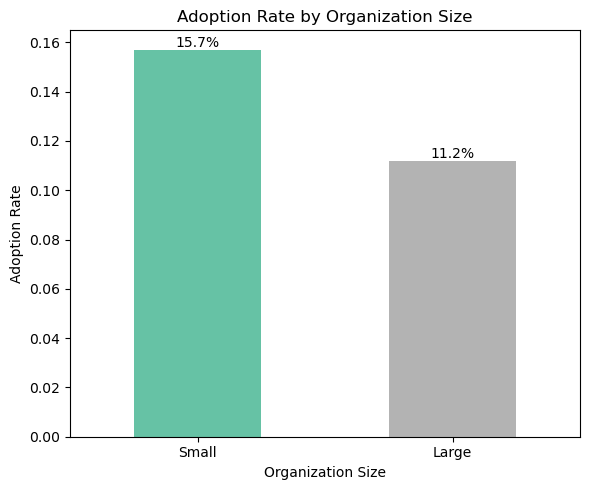

In [27]:
# Adoption rate by organization size

adoption_rate_by_org_size = (
    df_users
    .groupby("large_org")["adopted_user"]
    .mean()
)

plt.figure(figsize=(6, 5))

ax = adoption_rate_by_org_size.plot(
    kind="bar",
    color=plt.cm.Set2(np.linspace(0, 1, len(adoption_rate_by_org_size)))
)

ax.set_xlabel("Organization Size")
ax.set_ylabel("Adoption Rate")
ax.set_title("Adoption Rate by Organization Size")
ax.set_xticklabels(["Small", "Large"], rotation=0)

# Display adoption rate on each bar
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

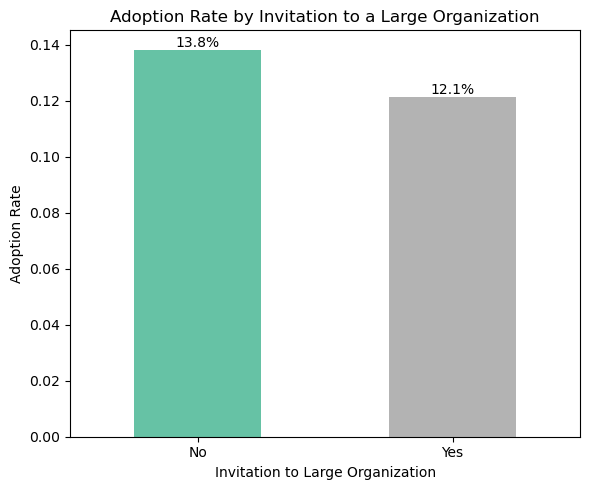

In [28]:
# Adoption rate by invitation into a large organization

adoption_rate_by_large_org_invitation = (
    df_users
    .groupby("invited_to_large_org")["adopted_user"]
    .mean()
)

plt.figure(figsize=(6, 5))

ax = adoption_rate_by_large_org_invitation.plot(
    kind="bar",
    color=plt.cm.Set2(np.linspace(0, 1, len(adoption_rate_by_large_org_invitation)))
)

ax.set_xlabel("Invitation to Large Organization")
ax.set_ylabel("Adoption Rate")
ax.set_title("Adoption Rate by Invitation to a Large Organization")
ax.set_xticklabels(["No", "Yes"], rotation=0)

# Display adoption rate on each bar
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

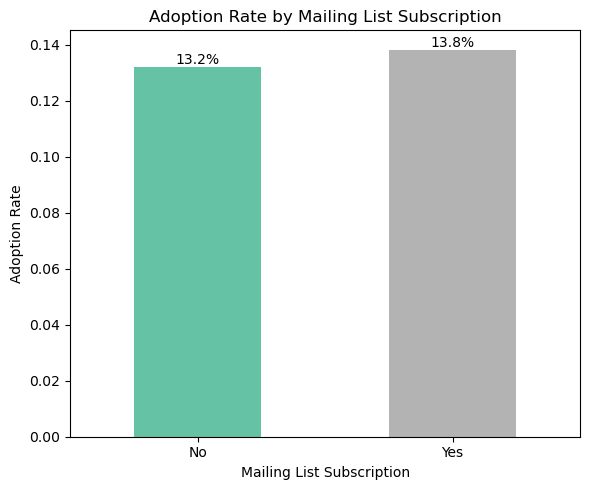

In [29]:
# Adoption rate by mailing list subscription

adoption_rate_by_mailing_list = (
    df_users
    .groupby("opted_in_to_mailing_list")["adopted_user"]
    .mean()
)

plt.figure(figsize=(6, 5))

ax = adoption_rate_by_mailing_list.plot(
    kind="bar",
    color=plt.cm.Set2(np.linspace(0, 1, len(adoption_rate_by_mailing_list)))
)

ax.set_xlabel("Mailing List Subscription")
ax.set_ylabel("Adoption Rate")
ax.set_title("Adoption Rate by Mailing List Subscription")
ax.set_xticklabels(["No", "Yes"], rotation=0)

# Display adoption rate on each bar
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

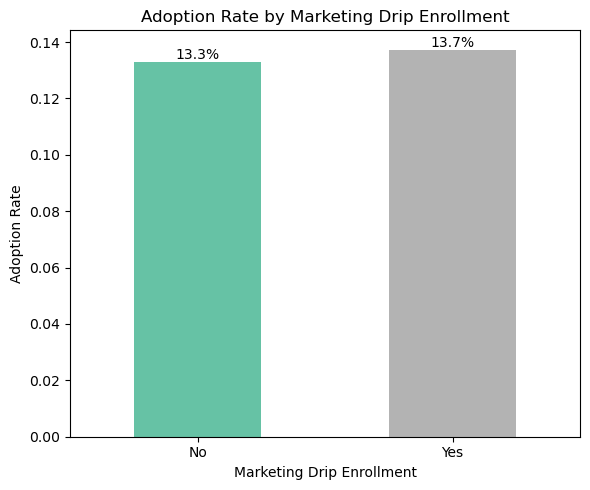

In [30]:
# Adoption rate by marketing drip enrollment

adoption_rate_by_marketing_drip = (
    df_users
    .groupby("enabled_for_marketing_drip")["adopted_user"]
    .mean()
)

plt.figure(figsize=(6, 5))

ax = adoption_rate_by_marketing_drip.plot(
    kind="bar",
    color=plt.cm.Set2(np.linspace(0, 1, len(adoption_rate_by_marketing_drip)))
)

ax.set_xlabel("Marketing Drip Enrollment")
ax.set_ylabel("Adoption Rate")
ax.set_title("Adoption Rate by Marketing Drip Enrollment")
ax.set_xticklabels(["No", "Yes"], rotation=0)

# Display adoption rate on each bar
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

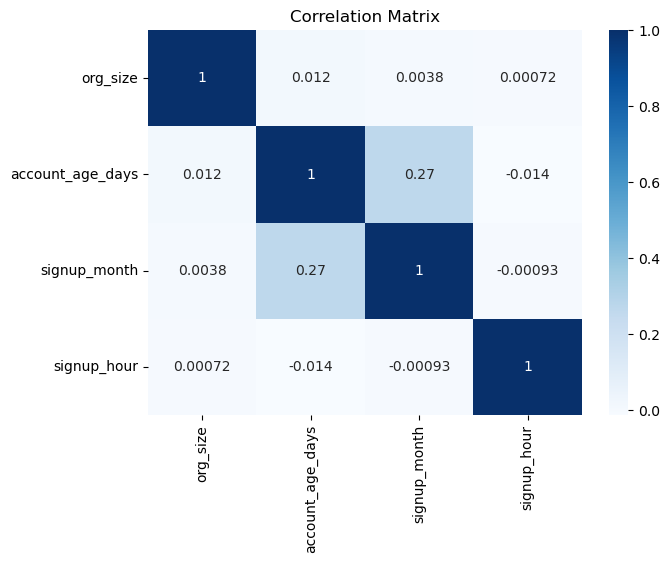

In [31]:
# Correlation Among Numerical Variables
numerical_features = [
    "org_size",
    "account_age_days",
    "signup_month",
    "signup_hour"
]

plt.figure(figsize=(7,5))

sns.heatmap(
    df_users[numerical_features].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

### Correlation Among Continuous Numerical Features

Correlation analysis was performed only on **continuous numerical variables** (`org_size`, `account_age_days`, `signup_month`, and `signup_hour`) rather than on every variable stored as an integer.

Although several variables in the dataset are represented using integer data types (e.g., `was_invited`, `large_org`, `opted_in_to_mailing_list`, `enabled_for_marketing_drip`, and `adopted_user`), these variables are **binary indicators (0/1)** rather than continuous measurements. Similarly, `org_id` is an **identifier** and does not possess any inherent numerical meaning.

The primary purpose of the correlation matrix is to identify potential **linear relationships and multicollinearity among continuous predictors** before model development. Binary variables are more appropriately analyzed using contingency tables (cross-tabulations), adoption rates, or statistical tests such as the Chi-square test, which provide more interpretable insights into their relationship with the target variable.

Accordingly, the correlation analysis focuses on the following continuous numerical features:

- **`org_size`** – Number of users within an organization.
- **`account_age_days`** – Number of days the account existed during the observation period. This variable is included in the exploratory analysis because it is a continuous numerical feature; however, it is **excluded from the predictive model** because it would not be available at the time a newly registered user signs up. Including it would make the model rely on information that is unavailable when generating real-time predictions for new users.
- **`signup_month`** – Month in which the user registered.
- **`signup_hour`** – Hour of the day the user registered.

> **Modeling Note:** To ensure the model reflects a real-world deployment scenario, `account_age_days` was excluded from model development because the objective is to predict adoption at the time of user registration, when this information is not yet available. Consequently, all models were trained using only features available at signup.
> 
> org_id was encoded using target encoding to capture organization-specific adoption patterns observed in the training data. While this improves predictive performance for organizations represented during training, these learned effects may not generalize to previously unseen organizations. Consequently, more general organizational features such as org_size and large_org are expected to provide more robust predictive information for new organizations encountered after deployment.

### Preprocessing and Modelling

In [32]:
# Remove identifiers and variables that do not contribute to prediction
X = df_users.drop(
    columns=[
        "object_id",
        "invited_by_user_id",
        "name",
        "email",
        "creation_time",
        "account_age_days",
        "adopted_user"
    ]
)

y = df_users["adopted_user"]

In [33]:
# Features identification
categorical_features = [
    "creation_source",
    "email_domain",
    "signup_weekday"
]

numeric_features = [
    "org_size",
    "large_org",
    "was_invited",
    "signup_month",
    "invited_to_large_org",
    "signup_hour",
    "inviter_total_invites",
    "opted_in_to_mailing_list",
    "enabled_for_marketing_drip"
]

In [34]:
# Pipeline for preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("org", TargetEncoder(smoothing=10), ["org_id"]),
        ("numeric", StandardScaler(), numeric_features),
    ],
    remainder="drop"
)

# Train Test Split the data
# Retain data structure by stratifying the dataset and ensure reproducibility
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

### Model Development

In [35]:
X_train.isna().sum()[X_train.isna().sum() > 0]

Series([], dtype: int64)

In [36]:
# Logistic Regression: 
# Selected as the baseline model due to its simplicity, interpretability,
# and ability to provide a benchmark against more complex machine learning models.
# class_weight="balanced" compensates for class imbalance by assigning
# greater weight to the minority class during model training, helping
# the model avoid bias toward the majority class.
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42
    ))
])

# Train the Logistic Regression model.
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['creation_source',
                                                   'email_domain',
                                                   'signup_weekday']),
                                                 ('org', TargetEncoder(),
                                                  ['org_id']),
                                                 ('numeric', StandardScaler(),
                                                  ['org_size', 'large_org',
                                                   'was_invited',
                                                   'signup_month',
                                                   'invited_to_large_org',
                                                   'signup_hour',
                                                   'inviter_total_invites',
                                                   'opted_in_to_mailing_list',
                                                   'enabled_for_marketing_drip'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [37]:
# Random Forest:
# Chosen next because it can capture complex non-linear
# relationships and interactions between features without requiring
# extensive feature engineering. It is also robust to outliers and
# provides feature importance for model interpretation.
# Since the target classes are imbalanced (approximately87% Not adopted vs. 13% adopted), 
# class_weight="balanced" assigns higher importance to the minority class during training.
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['creation_source',
                                                   'email_domain',
                                                   'signup_weekday']),
                                                 ('org', TargetEncoder(),
                                                  ['org_id']),
                                                 ('numeric', StandardScaler(),
                                                  ['org_size', 'large_org',
                                                   'was_invited',
                                                   'signup_month',
                                                   'invited_to_large_org',
                                                   'signup_hour',
                                                   'inviter_total_invites',
                                                   'opted_in_to_mailing_list',
                                                   'enabled_for_marketing_drip'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [38]:
# XGBoost

# scale_pos_weight uses this ratio to increase the loss associated with
# misclassifying minority-class examples, helping address class imbalance
# during training without changing the original data distribution.
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

# Train the XGBoost classifier.
# XGBoost is selected because it is a high-performance gradient boosting
# algorithm that captures complex non-linear patterns and feature
# interactions. It also incorporates regularization to reduce
# overfitting and is widely recognized as one of the strongest models
# for structured (tabular) machine learning tasks.

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['creation_source',
                                                   'email_domain',
                                                   'signup_weekday']),
                                                 ('org', TargetEncoder(),
                                                  ['org_id']),
                                                 ('numeric', StandardScaler(),
                                                  ['org_size', 'large_org',
                                                   'was_invited',
                                                   'signup_month',
                                                   'invited_to_large_org',
                                                   'signup_hour',
                                                   'inviter_total_invites',
                                                   'o...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [39]:
# Train the LightGBM classifier.
# LightGBM is selected because it is an efficient gradient boosting
# algorithm that trains quickly while maintaining high predictive
# performance. It uses a leaf-wise tree growth strategy to capture
# complex non-linear relationships and feature interactions, making it
# well suited for structured (tabular) classification problems.

lgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        class_weight="balanced",
        random_state=42,
        verbosity=-1
    ))
])

lgbm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['creation_source',
                                                   'email_domain',
                                                   'signup_weekday']),
                                                 ('org', TargetEncoder(),
                                                  ['org_id']),
                                                 ('numeric', StandardScaler(),
                                                  ['org_size', 'large_org',
                                                   'was_invited',
                                                   'signup_month',
                                                   'invited_to_large_org',
                                                   'signup_hour',
                                                   'inviter_total_invites',
                                                   'opted_in_to_mailing_list',
                                                   'enabled_for_marketing_drip'])])),
                ('classifier',
                 LGBMClassifier(class_weight='balanced', learning_rate=0.05,
                                max_depth=4, n_estimators=300, random_state=42,
                                verbosity=-1))])

In [40]:
# Define an evaluation model for selection of the champion model
# Function to evaluate a classification model

def evaluate_model(name, model, X_test, y_test):

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    }

In [41]:
# Evaluate all models

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        lr_model,
        X_test,
        y_test
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_test,
        y_test
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        xgb_model,
        X_test,
        y_test
    )
)

# Include LightGBM only if it was trained
results.append(
    evaluate_model(
        "LightGBM",
        lgbm_model,
        X_test,
        y_test
    )
)

results_df = (
    pd.DataFrame(results)
      .sort_values(
          by="ROC-AUC",
          ascending=False
      )
      .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LightGBM,0.653750,0.195471,0.512500,0.283003,0.623077
1,Logistic Regression,0.538333,0.174380,0.659375,0.275817,0.619267
2,Random Forest,0.865833,0.000000,0.000000,0.000000,0.584171
3,XGBoost,0.760417,0.191283,0.246875,0.215553,0.566895


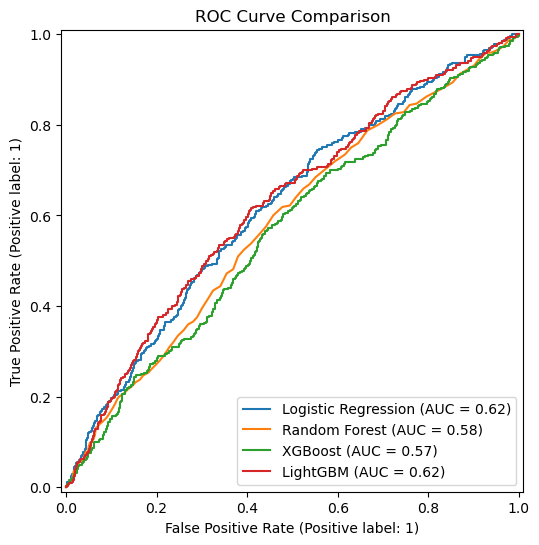

In [42]:
# Compare ROC Curves
# Visualizing the ROC curvesprovides an additional comparison of each model's ability
# to distinguish adopted users from non-adopted users across all classification thresholds.
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

plt.figure(figsize=(8,6))

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title("ROC Curve Comparison")

plt.show()

In [43]:
# Cross-Validation and Model Robustness
# A strong performance on the test set alone does not guarantee that a model will generalize well to unseen data.
# To evaluate model stability, perform 5-fold cross-validation using ROC-AUC as the evaluation metric.

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

cv_results = []

for name, model in models.items():

    cv_auc = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="roc_auc"
    )

    cv_results.append({

        "Model": name,

        "Mean CV ROC-AUC": cv_auc.mean(),

        "Std Dev": cv_auc.std()

    })

cv_results_df = (
    pd.DataFrame(cv_results)
      .sort_values(
          "Mean CV ROC-AUC",
          ascending=False
      )
      .reset_index(drop=True)
)

cv_results_df

,Model,Mean CV ROC-AUC,Std Dev
0,LightGBM,0.616521,0.006998
1,Logistic Regression,0.609826,0.013300
2,Random Forest,0.592554,0.007886
3,XGBoost,0.574413,0.011693


In [44]:
# Champion Model Selection

champion_model = results_df.iloc[0]["Model"]

print(f"Champion Model: {champion_model}")

Champion Model: LightGBM


**LightGBM was selected as the champion model** because it achieved the **highest test ROC-AUC (0.623) and the highest mean cross-validation ROC-AUC (0.616),** indicating the **strongest and most consistent ability to distinguish adopted users from non-adopted users.** The ROC curves also show that LightGBM consistently performs at or above the other models across most classification thresholds.

Although Logistic Regression produced a similar ROC-AUC (0.619) and slightly higher recall (0.659), **LightGBM provided the best overall discriminative performance while capturing more complex, non-linear relationships**. Random Forest was not selected despite its high accuracy (86.5%), as its extremely low recall (0.006) indicates it failed to identify adopted users. XGBoost produced the weakest ROC-AUC (0.605) and therefore demonstrated the lowest predictive performance.

#### Model Impotance

In [45]:
feature_names = lgbm_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": lgbm_model.named_steps[
        "classifier"
    ].feature_importances_

})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance.head(15)

,Feature,Importance
19,org__org_id,905
25,numeric__signup_hour,620
20,numeric__org_size,569
23,numeric__signup_month,511
26,numeric__inviter_total_invites,277
2,categorical__creation_source_PERSONAL_PROJECTS,87
7,categorical__email_domain_gustr.com,81
6,categorical__email_domain_gmail.com,78
15,categorical__signup_weekday_Sunday,77
17,categorical__signup_weekday_Tuesday,74


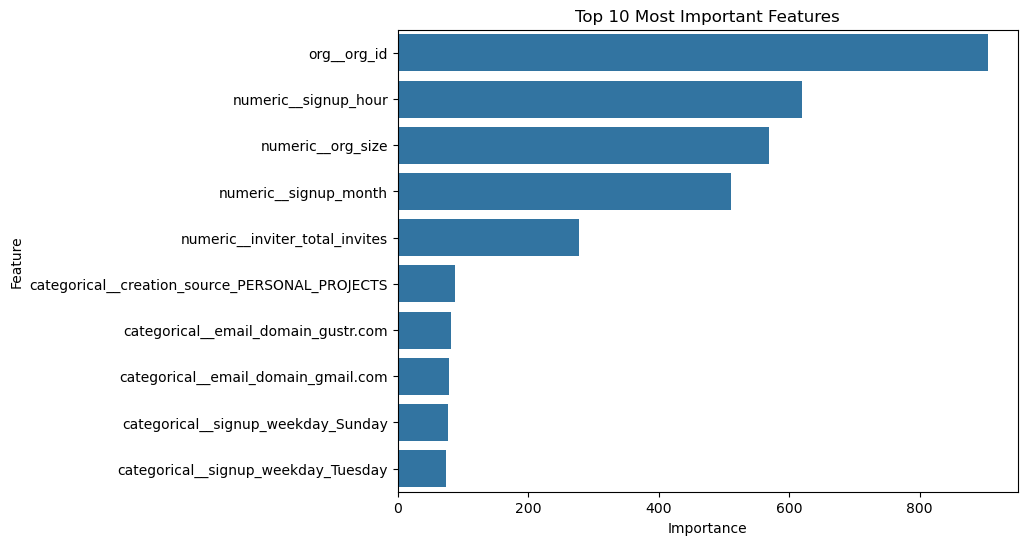

In [46]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Most Important Features")

plt.show()

In [47]:
X

,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,was_invited,org_size,signup_month,signup_weekday,signup_hour,large_org,invited_to_large_org,email_domain,inviter_total_invites
0,GUEST_INVITE,1,0,11,1,75,4,Tuesday,3,1,1,yahoo.com,1.0
1,ORG_INVITE,0,0,1,1,233,11,Friday,3,1,1,gustr.com,3.0
2,ORG_INVITE,0,0,94,1,32,3,Tuesday,23,1,1,gustr.com,11.0
3,GUEST_INVITE,0,0,1,1,233,5,Tuesday,8,1,1,yahoo.com,7.0
4,GUEST_INVITE,0,0,193,1,16,1,Thursday,10,0,0,yahoo.com,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,ORG_INVITE,0,0,89,1,40,9,Friday,6,1,1,gustr.com,7.0
11996,SIGNUP_GOOGLE_AUTH,0,0,200,0,25,1,Thursday,18,0,0,gmail.com,0.0
11997,GUEST_INVITE,1,1,83,1,27,4,Sunday,12,0,0,cuvox.de,5.0
11998,PERSONAL_PROJECTS,0,0,6,0,138,5,Thursday,11,1,0,other,0.0
